[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yel1owHatGuy/Machine-Learning-2025L/blob/master/Homeworks/lab1_hw.ipynb)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import sklearn

In [2]:
data = pd.read_csv("../PCA_three_clusters_data.csv")

In [3]:
data.head()

,x,y,z,class
0,0.647689,-0.138264,3.512299,0
1,-0.234137,-0.234153,10.769447,0
2,-0.469474,0.767435,11.166721,0
3,-0.465730,-0.463418,3.836479,0
4,-1.724918,-1.913280,1.710932,0


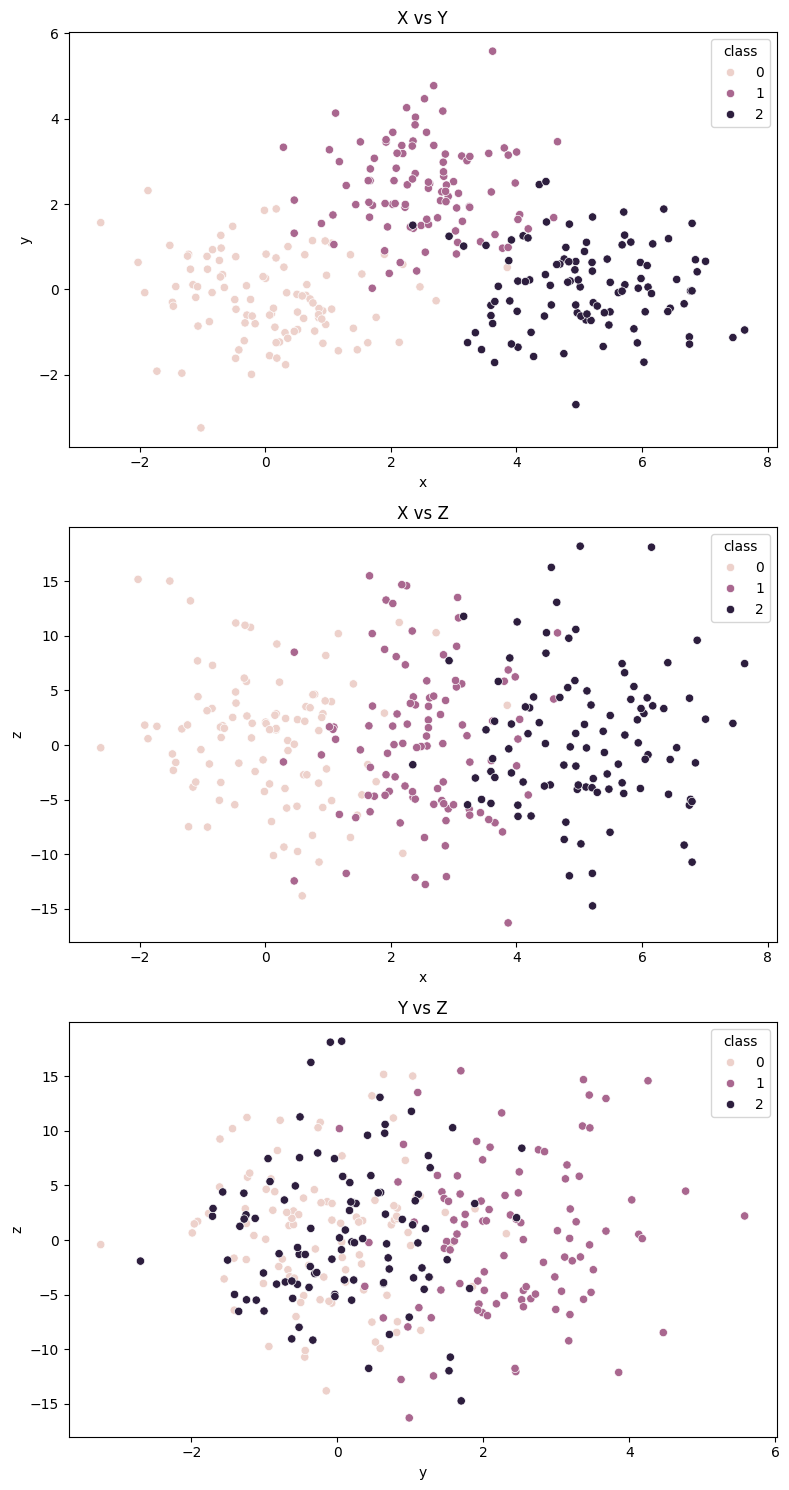

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

sns.scatterplot(x='x', y='y', data=data, hue='class', ax=axes[0])
axes[0].set_title('X vs Y')

sns.scatterplot(x='x', y='z', data=data, hue='class', ax=axes[1])
axes[1].set_title('X vs Z')

sns.scatterplot(x='y', y='z', data=data, hue='class', ax=axes[2])
axes[2].set_title('Y vs Z')

plt.tight_layout()
plt.show()


In [5]:
print("Data before scaling:")
print(data.loc[:, ['x','y','z']].describe())
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.loc[:, ['x','y','z']])
print("Data after scaling:")
print(pd.DataFrame(data_scaled, columns=['x', 'y', 'z']).describe())


Data before scaling:
                x           y           z
count  300.000000  300.000000  300.000000
mean     2.561883    0.759617    0.473686
std      2.300371    1.529409    6.326528
min     -2.619745   -3.241267  -16.277041
25%      0.701033   -0.441662   -3.998547
50%      2.557802    0.633425    0.563007
75%      4.382826    1.822406    4.104527
max      7.632382    5.578881   18.196402
Data after scaling:
                x             y             z
count  300.000000  3.000000e+02  3.000000e+02
mean     0.000000  4.736952e-17  5.921189e-18
std      1.001671  1.001671e+00  1.001671e+00
min     -2.256282 -2.620338e+00 -2.652120e+00
25%     -0.810286 -7.867652e-01 -7.080828e-01
50%     -0.001777 -8.264774e-02  1.414215e-02
75%      0.792909  6.960628e-01  5.748664e-01
max      2.207892  3.156327e+00  2.806014e+00


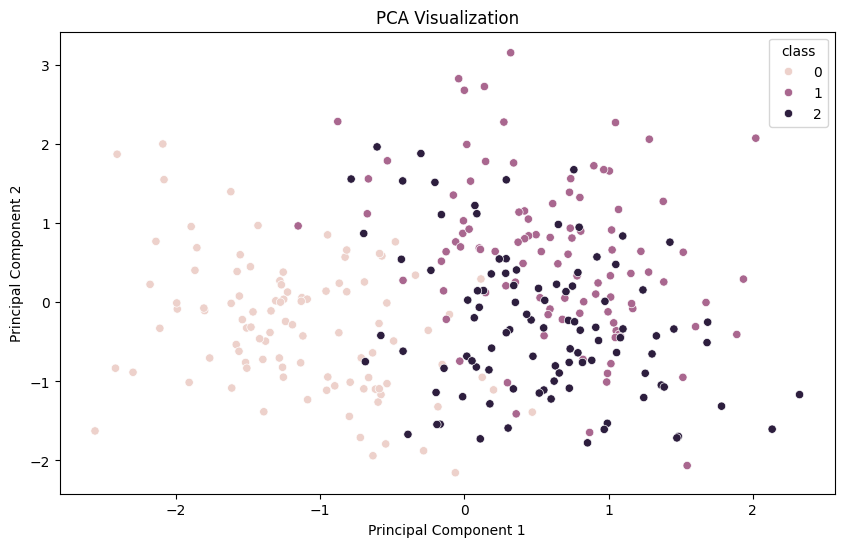

In [6]:
target = data['class']
pca = PCA(n_components = 3)
XV = pca.fit_transform(data_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=XV[:, 0], y=XV[:, 1], hue=target)
plt.title('PCA Visualization')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [7]:
print("\nCumulative explained percentage variance\n")
print(np.cumsum(pca.explained_variance_ratio_))


Cumulative explained percentage variance

[0.34722276 0.68164111 1.        ]


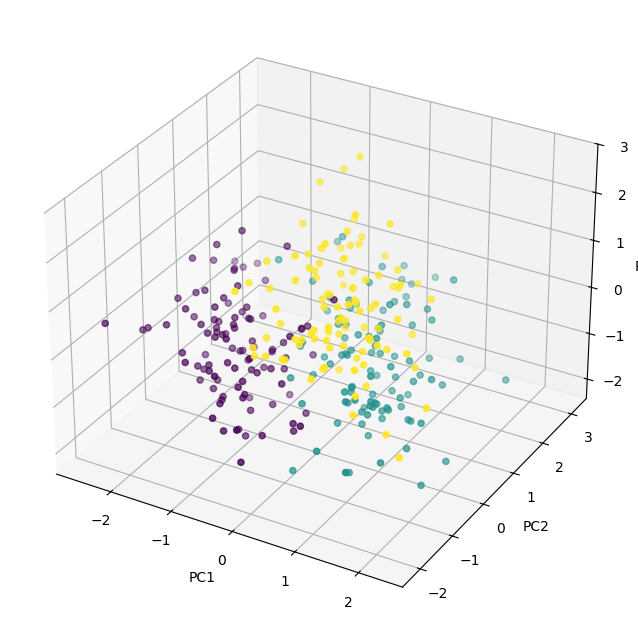

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(XV[:, 0], XV[:, 1], XV[:, 2], c=target, cmap='viridis')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

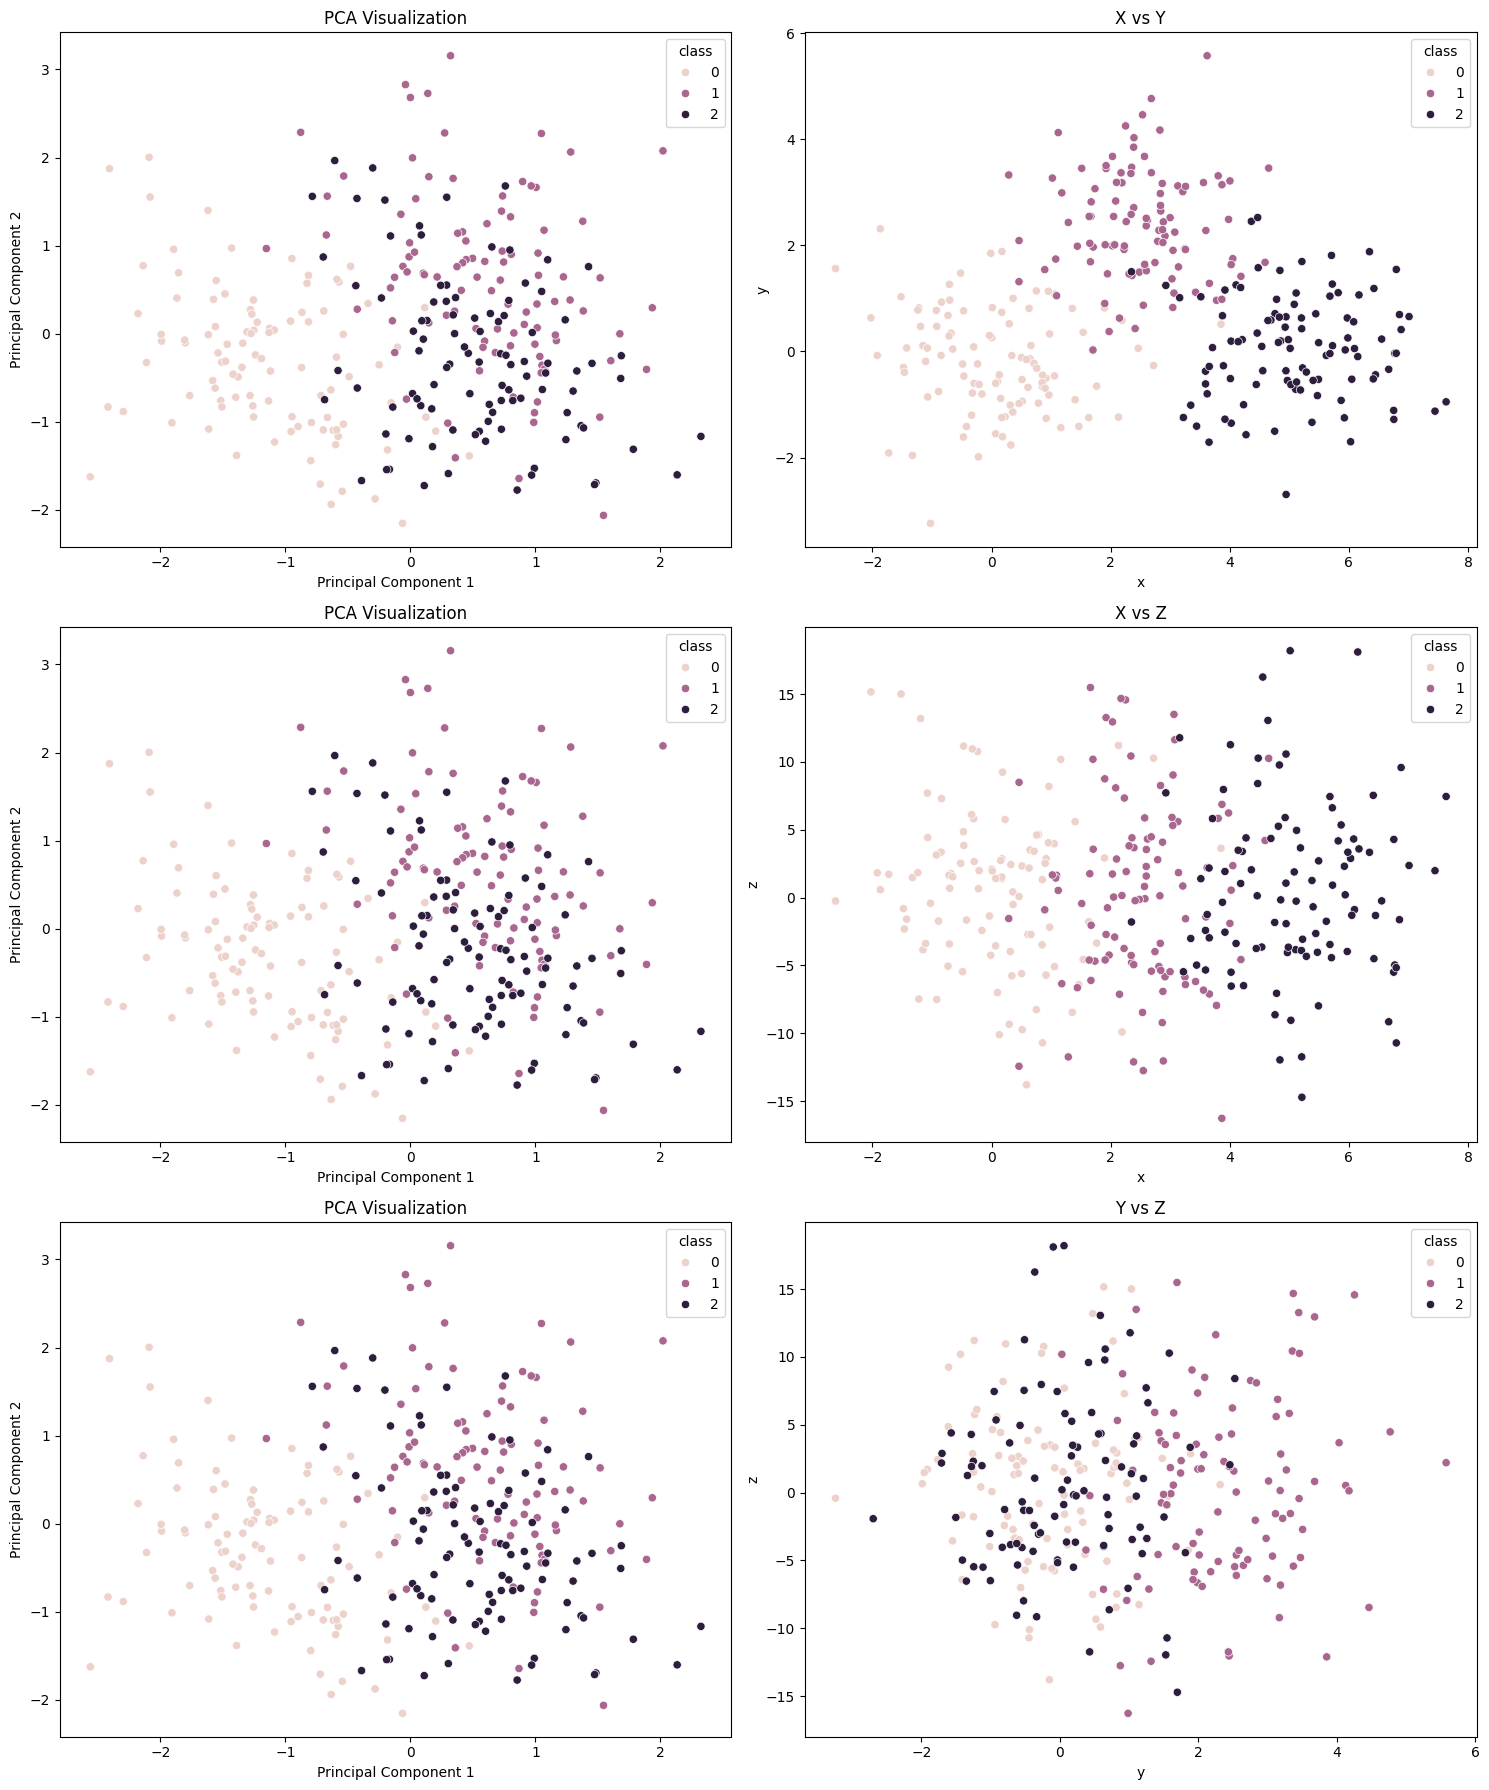

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

sns.scatterplot(x=XV[:, 0], y=XV[:, 1], hue=target, ax=axes[0, 0])
axes[0, 0].set_title('PCA Visualization')
axes[0, 0].set_xlabel("Principal Component 1")
axes[0, 0].set_ylabel("Principal Component 2")

sns.scatterplot(x='x', y='y', data=data, hue='class', ax=axes[0, 1])
axes[0, 1].set_title('X vs Y')

sns.scatterplot(x=XV[:, 0], y=XV[:, 1], hue=target, ax=axes[1, 0])
axes[1, 0].set_title('PCA Visualization')
axes[1, 0].set_xlabel("Principal Component 1")
axes[1, 0].set_ylabel("Principal Component 2")

sns.scatterplot(x='x', y='z', data=data, hue='class', ax=axes[1, 1])
axes[1, 1].set_title('X vs Z')

sns.scatterplot(x=XV[:, 0], y=XV[:, 1], hue=target, ax=axes[2, 0])
axes[2, 0].set_title('PCA Visualization')
axes[2, 0].set_xlabel("Principal Component 1")
axes[2, 0].set_ylabel("Principal Component 2")

sns.scatterplot(x='y', y='z', data=data, hue='class', ax=axes[2, 1])
axes[2, 1].set_title('Y vs Z')

plt.tight_layout()
plt.show()


Does PCA improve the separation of data points from different clusters compared to the original feature spaces? Explain why.

Moim zdaniem, PCA nie zwiększyla separacji danych w porównaniu do oryginalnej przestrzeni cech. Widać, że PCA nie było w stanie znaleźć odpowiedniego oddzielenia między klastrami, potwierdza to fakt, że wyjaśniona wariancja dla pierwszych dwóch komponentów wynosi około 68%, natomiast pierwszy komponent wyjaśnia jej okolo 35%, co może oznaczać, że całe dane nie mogą być dobrze opisane w dwóch wymiarach. Dobrze obrazuje to  wykres 3D.


**Why is standardization necessary before applying PCA?**

- Explain how differences in scale among features can impact the principal component directions.

Standaryzacja danych przed zastosowaniem PCA jest kluczowa, ponieważ PCA jest wrażliwa na skalę danych. Jeśli dane nie są standaryzowane, PCA może skupić się na zmiennych o większej skali, co może prowadzić do błędnych wniosków. Standaryzacja danych zapewnia, że każda zmienna ma średnią 0 i odchylenie standardowe 1, co pozwala PCA na identyfikację rzeczywistych wzorców w danych.

Dla demonstracji, użyjemy PCA dla danych, w których jedna ze zmiennych nie jest ustandaryzowana.

In [23]:
print(data.loc[:, ['x','y','z']].describe())
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[['x', 'y']])

data_scaled_df = pd.DataFrame(data_scaled, columns=['x', 'y'])
data_scaled_df['z'] = data['z'].values 

                x           y           z
count  300.000000  300.000000  300.000000
mean     2.561883    0.759617    0.473686
std      2.300371    1.529409    6.326528
min     -2.619745   -3.241267  -16.277041
25%      0.701033   -0.441662   -3.998547
50%      2.557802    0.633425    0.563007
75%      4.382826    1.822406    4.104527
max      7.632382    5.578881   18.196402


In [24]:
print(data_scaled_df.describe())

                x             y           z
count  300.000000  3.000000e+02  300.000000
mean     0.000000  4.736952e-17    0.473686
std      1.001671  1.001671e+00    6.326528
min     -2.256282 -2.620338e+00  -16.277041
25%     -0.810286 -7.867652e-01   -3.998547
50%     -0.001777 -8.264774e-02    0.563007
75%      0.792909  6.960628e-01    4.104527
max      2.207892  3.156327e+00   18.196402


In [34]:
pca_scaled = PCA(n_components=2)
pca_scaled.fit_transform(data_scaled_df)
loadings = pd.DataFrame(
    pca_scaled.components_.T,
    columns=['PC1', 'PC2'],
    index=['x', 'y', 'z']
)
print(loadings)
print("Explained variance (ze standaryzacją dwóch zmiennych):", pca_scaled.explained_variance_ratio_)

        PC1       PC2
x -0.004164  0.703740
y  0.000550  0.710453
z  0.999991  0.002539
Explained variance (ze standaryzacją dwóch zmiennych): [0.95227404 0.02469662]


In [32]:
data_all_scaled = pd.DataFrame(
    StandardScaler().fit_transform(data[['x', 'y', 'z']]),
    columns=['x', 'y', 'z']
)

pca_all = PCA(n_components=2)
pca_all.fit(data_all_scaled)

loadings_all = pd.DataFrame(
    pca_all.components_.T,
    columns=['PC1', 'PC2'],
    index=['x', 'y', 'z']
)
print(loadings_all)
print("Explained variance (standaryzacja wszystkich zmiennych):", pca_all.explained_variance_ratio_)

        PC1       PC2
x  0.720058 -0.023683
y  0.569460  0.591267
z -0.396525  0.806128
Explained variance (standaryzacja wszystkich zmiennych): [0.34722276 0.33441835]


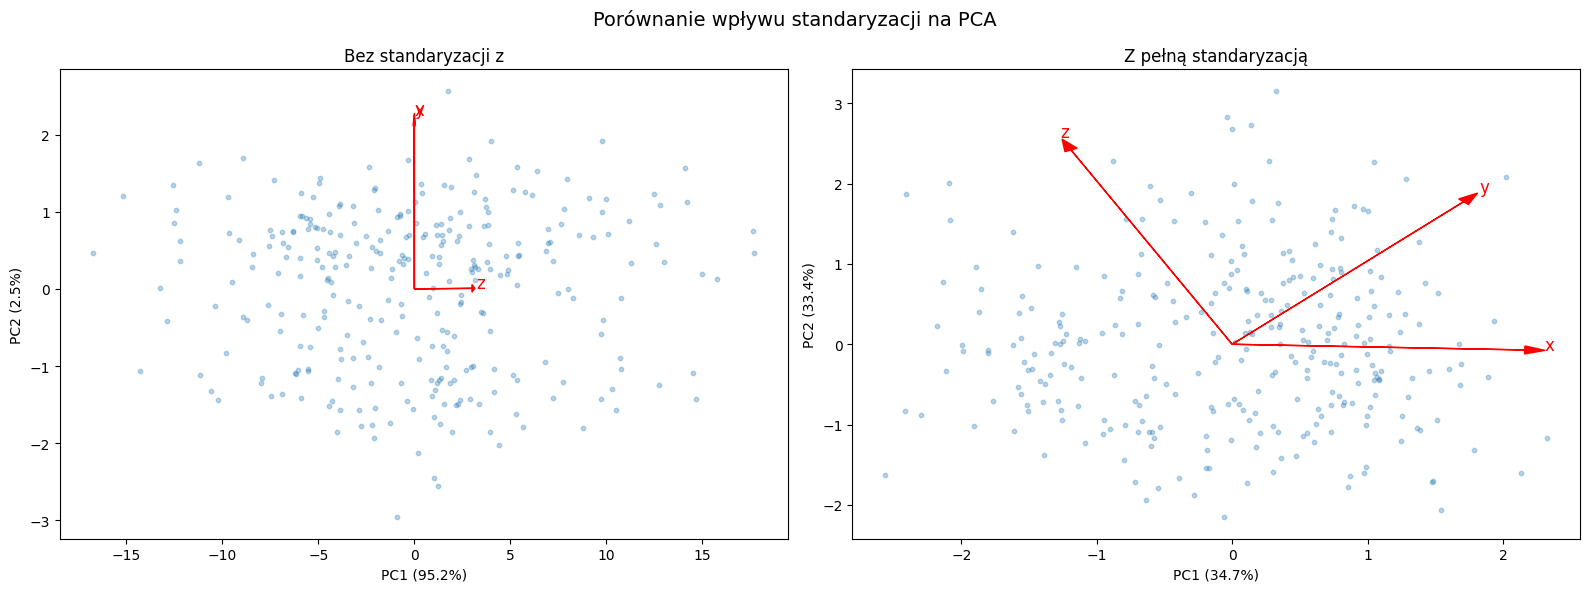

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

components_scaled = pca_scaled.transform(data_scaled_df)

axes[0].scatter(components_scaled[:, 0], components_scaled[:, 1], alpha=0.3, s=10)
for i, var in enumerate(['x', 'y', 'z']):
    axes[0].arrow(0, 0,
                  pca_scaled.components_[0, i] * 3,
                  pca_scaled.components_[1, i] * 3,
                  head_width=0.1, color='red')
    axes[0].text(pca_scaled.components_[0, i] * 3.2,
                 pca_scaled.components_[1, i] * 3.2,
                 var, fontsize=12, color='red')
axes[0].set_xlabel(f'PC1 ({pca_scaled.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_scaled.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Bez standaryzacji z')

components_all = pca_all.transform(data_all_scaled)

axes[1].scatter(components_all[:, 0], components_all[:, 1], alpha=0.3, s=10)
for i, var in enumerate(['x', 'y', 'z']):
    axes[1].arrow(0, 0,
                  pca_all.components_[0, i] * 3,
                  pca_all.components_[1, i] * 3,
                  head_width=0.1, color='red')
    axes[1].text(pca_all.components_[0, i] * 3.2,
                 pca_all.components_[1, i] * 3.2,
                 var, fontsize=12, color='red')
axes[1].set_xlabel(f'PC1 ({pca_all.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_all.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Z pełną standaryzacją')

plt.suptitle('Porównanie wpływu standaryzacji na PCA', fontsize=14)
plt.tight_layout()
plt.show()

Jak widać wyniki PCA gdy jedna ze zmiennych nie jest ustandaryzowana, znacząco odbiegają od rezultatów PCA przeprowadzanego na poprawnie przygotowanych danych.